In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

In [59]:
df = pd.read_parquet("../../../data/churn-prediction-25-26/train.parquet")

In [3]:
df["date"] = pd.to_datetime(df["time"]).dt.date
df_total_time_df = df.groupby("date")["length"].sum().reset_index()

#df_churn_per_day = df[df["page"] == "Cancellation Confirmation"]

In [60]:
df[df["page"] == "Cancellation Confirmation"]["userId"].nunique()

4271

In [61]:
df["userId"].nunique()

19140

In [ ]:
df_plot = pd.DataFrame(
    data = {
        "Number of Churned Users": [4271],
        "Number of Non-churned Users": [19140]
    }
)

/var/folders/kn/2hccvkp11655sjfyptcwpt0h0000gn/T/ipykernel_85750/3025234528.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=10, ha="right")


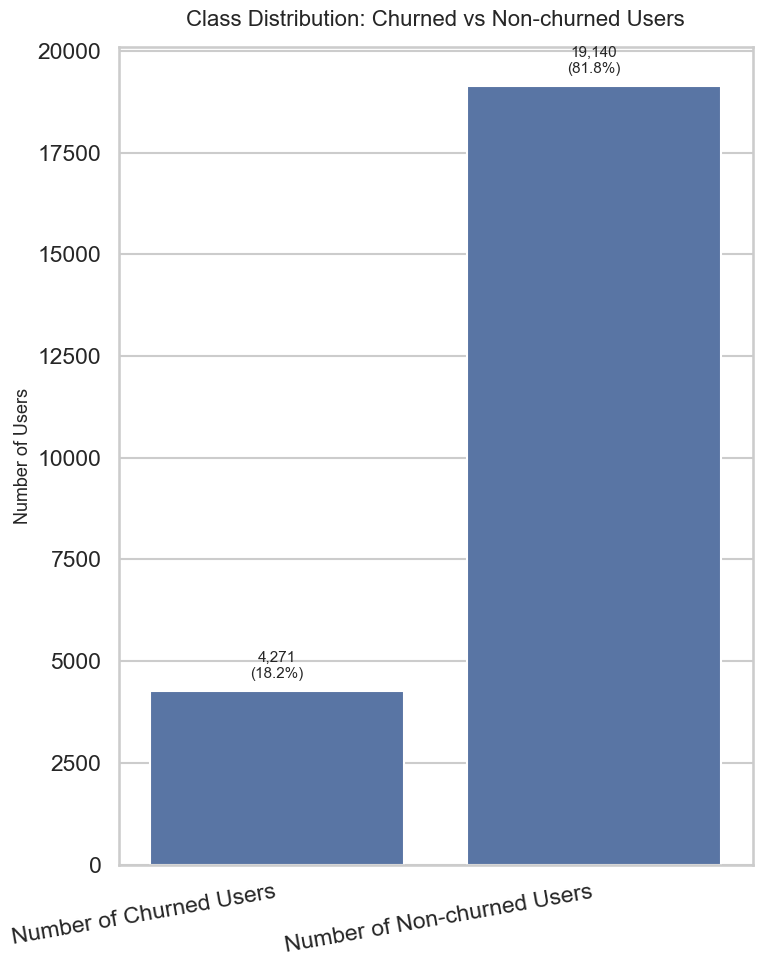

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = pd.DataFrame(
    data={
        "Number of Churned Users": [4271],
        "Number of Non-churned Users": [19140]
    }
)

# ---- 1. Reshape to long format ----
df_long = df_plot.melt(
    var_name="Class",
    value_name="Count"
)

# ---- 2. Nice barplot ----
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(8, 10))

sns.barplot(
    data=df_long,
    x="Class",
    y="Count",
    ax=ax
)

ax.set_title("Class Distribution: Churned vs Non-churned Users", fontsize=16, pad=15)
ax.set_xlabel("")
ax.set_ylabel("Number of Users", fontsize=13)

# Rotate x labels a bit so they don’t collide
ax.set_xticklabels(ax.get_xticklabels(), rotation=10, ha="right")

# ---- 3. Add count + percentage on top of each bar ----
total = df_long["Count"].sum()

for p in ax.patches:
    height = p.get_height()
    percentage = height / total
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height + total * 0.01,        # a bit above the bar
        s=f"{int(height):,}\n({percentage:.1%})",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()


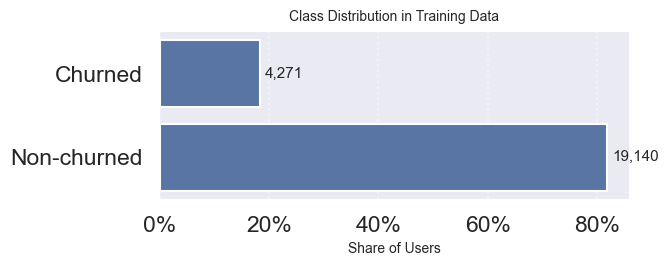

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Your data
df_plot = pd.DataFrame(
    data={
        "Number of Churned Users": [4271],
        "Number of Non-churned Users": [19140]
    }
)

# Long format + simpler labels
df_long = df_plot.melt(var_name="Class", value_name="Count")
df_long["Class"] = df_long["Class"].replace({
    "Number of Churned Users": "Churned",
    "Number of Non-churned Users": "Non-churned",
})

# Percentage
total = df_long["Count"].sum()
df_long["Percent"] = df_long["Count"] / total

sns.set_theme(context="talk")  # light, readable defaults

fig, ax = plt.subplots(figsize=(7, 3))

# Horizontal bar plot of percentages
sns.barplot(
    data=df_long,
    x="Percent",
    y="Class",
    ax=ax,
    orient="h",
)

# Titles / labels
ax.set_title("Class Distribution in Training Data", fontsize=10, pad=8)
ax.set_xlabel("Share of Users", fontsize=10)
ax.set_ylabel("")

# Format x-axis as %
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

# Add raw counts at the end of each bar
for p, (_, row) in zip(ax.patches, df_long.iterrows()):
    ax.text(
        x=p.get_width() + 0.01,  # a bit to the right of the bar
        y=p.get_y() + p.get_height() / 2,
        s=f"{int(row['Count']):,}",
        va="center",
        ha="left",
        fontsize=11,
    )

# Clean up the frame
sns.despine(left=True, bottom=True)
ax.grid(axis="x", linestyle=":", alpha=0.4)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()


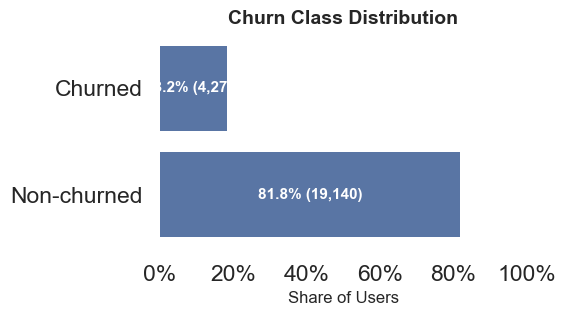

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Your data
df_plot = pd.DataFrame(
    data={
        "Number of Churned Users": [4271],
        "Number of Non-churned Users": [19140]
    }
)

# Reshape + simplify labels
df_long = df_plot.melt(var_name="Class", value_name="Count")
df_long["Class"] = df_long["Class"].replace({
    "Number of Churned Users": "Churned",
    "Number of Non-churned Users": "Non-churned",
})

# Compute percentages
total = df_long["Count"].sum()
df_long["Percent"] = df_long["Count"] / total

# --- Plot ---
sns.set_theme(style="white", context="talk")

fig, ax = plt.subplots(figsize=(6, 3.5))

# Horizontal bar plot of percentages
sns.barplot(
    data=df_long,
    x="Percent",
    y="Class",
    ax=ax,
    orient="h",
    edgecolor="none"
)

# Titles / labels
ax.set_title("Churn Class Distribution", fontsize=14, weight="bold", pad=8)
ax.set_xlabel("Share of Users", fontsize=12)
ax.set_ylabel("")

# Percent axis formatting (0–100%)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

# Remove clutter
sns.despine(left=True, bottom=True)
ax.grid(False)

# Add % + count centered in each bar
for p, (_, row) in zip(ax.patches, df_long.iterrows()):
    x_center = p.get_width() / 2
    y_center = p.get_y() + p.get_height() / 2

    label = f"{row['Percent']:.1%} ({int(row['Count']):,})"
    ax.text(
        x_center,
        y_center,
        label,
        ha="center",
        va="center",
        color="white",
        fontsize=11,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()


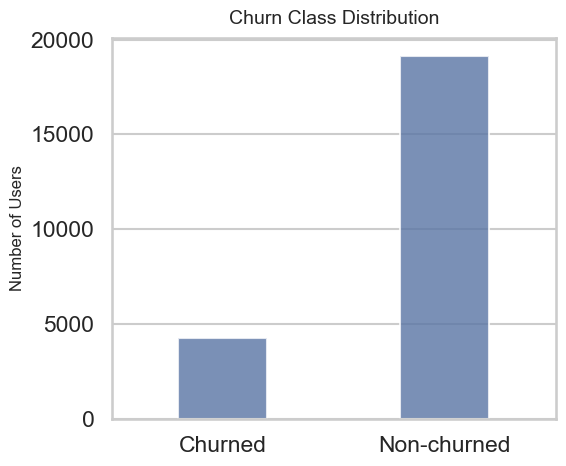

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = pd.DataFrame(
    {
        "Number of Churned Users": [4271],
        "Number of Non-churned Users": [19140],
    }
)

# Reshape + simplify labels
df_long = df_plot.melt(var_name="Class", value_name="Count")
df_long["Class"] = df_long["Class"].replace({
    "Number of Churned Users": "Churned",
    "Number of Non-churned Users": "Non-churned",
})

sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(6, 5))

sns.barplot(data=df_long, x="Class", y="Count", ax=ax, width=0.4, alpha=0.8)

ax.set_title("Churn Class Distribution", fontsize=14, pad=10)
ax.set_xlabel("")
ax.set_ylabel("Number of Users", fontsize=12)
"""
# Put just the counts above each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height,
        s=f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11,
    ) """

plt.tight_layout()
plt.show()


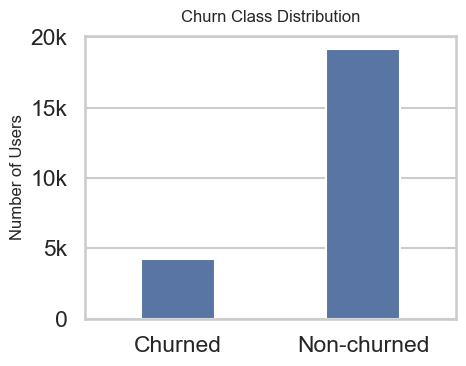

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

df_plot = pd.DataFrame(
    {
        "Number of Churned Users": [4271],
        "Number of Non-churned Users": [19140],
    }
)

# Reshape + simplify labels
df_long = df_plot.melt(var_name="Class", value_name="Count")
df_long["Class"] = df_long["Class"].replace({
    "Number of Churned Users": "Churned",
    "Number of Non-churned Users": "Non-churned",
})

sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(5, 4))

sns.barplot(
    data=df_long,
    x="Class",
    y="Count",
    ax=ax,
    width=0.4,  # slimmer bars
)

ax.set_title("Churn Class Distribution", fontsize=12, pad=10)
ax.set_xlabel("")
ax.set_ylabel("Number of Users", fontsize=12)

# --- format y-axis as 0, 5k, 10k, 15k, ... ---
def thousands_formatter(x, pos):
    if x >= 1000:
        return f"{int(x/1000):d}k"
    return f"{int(x):d}"

ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
"""
# Counts above bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height,
        s=f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11,
    )
"""
plt.tight_layout()
plt.show()


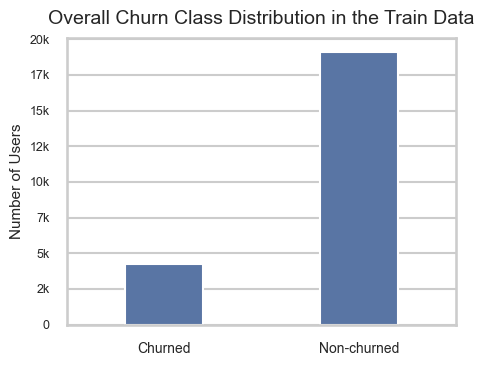

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

df_plot = pd.DataFrame(
    {
        "Number of Churned Users": [4271],
        "Number of Non-churned Users": [19140],
    }
)

# Reshape + simplify labels
df_long = df_plot.melt(var_name="Class", value_name="Count")
df_long["Class"] = df_long["Class"].replace({
    "Number of Churned Users": "Churned",
    "Number of Non-churned Users": "Non-churned",
})

sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(5, 4))

sns.barplot(
    data=df_long,
    x="Class",
    y="Count",
    ax=ax,
    width=0.4,  # slimmer bars
)

ax.set_title("Overall Churn Class Distribution in the Train Data", fontsize=14, pad=10)
ax.set_xlabel("")
ax.set_ylabel("Number of Users", fontsize=11)

# --- format y-axis as 0, 5k, 10k, ... ---
def thousands_formatter(x, pos):
    if x >= 1000:
        return f"{int(x/1000):d}k"
    return f"{int(x):d}"

ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

# ↓↓↓ smaller tick label font sizes ↓↓↓
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=10)
"""
# Counts above bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height,
        s=f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
"""
plt.tight_layout()
plt.show()


In [42]:
df["churn"] = df["userId"].isin(df_skewed_churn["userId"]).astype(int)

In [53]:
df_a = df[["userId", "churn"]].drop_duplicates()

In [54]:
df_a = df_a.groupby(["churn"]).sum().reset_index(name="number of users")

TypeError: DataFrame.reset_index() got an unexpected keyword argument 'name'

In [55]:
df_a

,userId,churn
0,1749042,1
1,1563081,0
2,1697168,0
3,1222580,1
4,1714398,0
...,...,...
25646375,1494594,0
25646627,1036641,0
25650010,1110980,0
25650509,1594272,0


In [4]:
#df_churn_per_day["churn"] = 1

In [5]:
#df_churn_per_day_sum = df_churn_per_day.groupby("date")["churn"].sum().reset_index()

In [6]:
#df_churn_per_day_sum.sample()

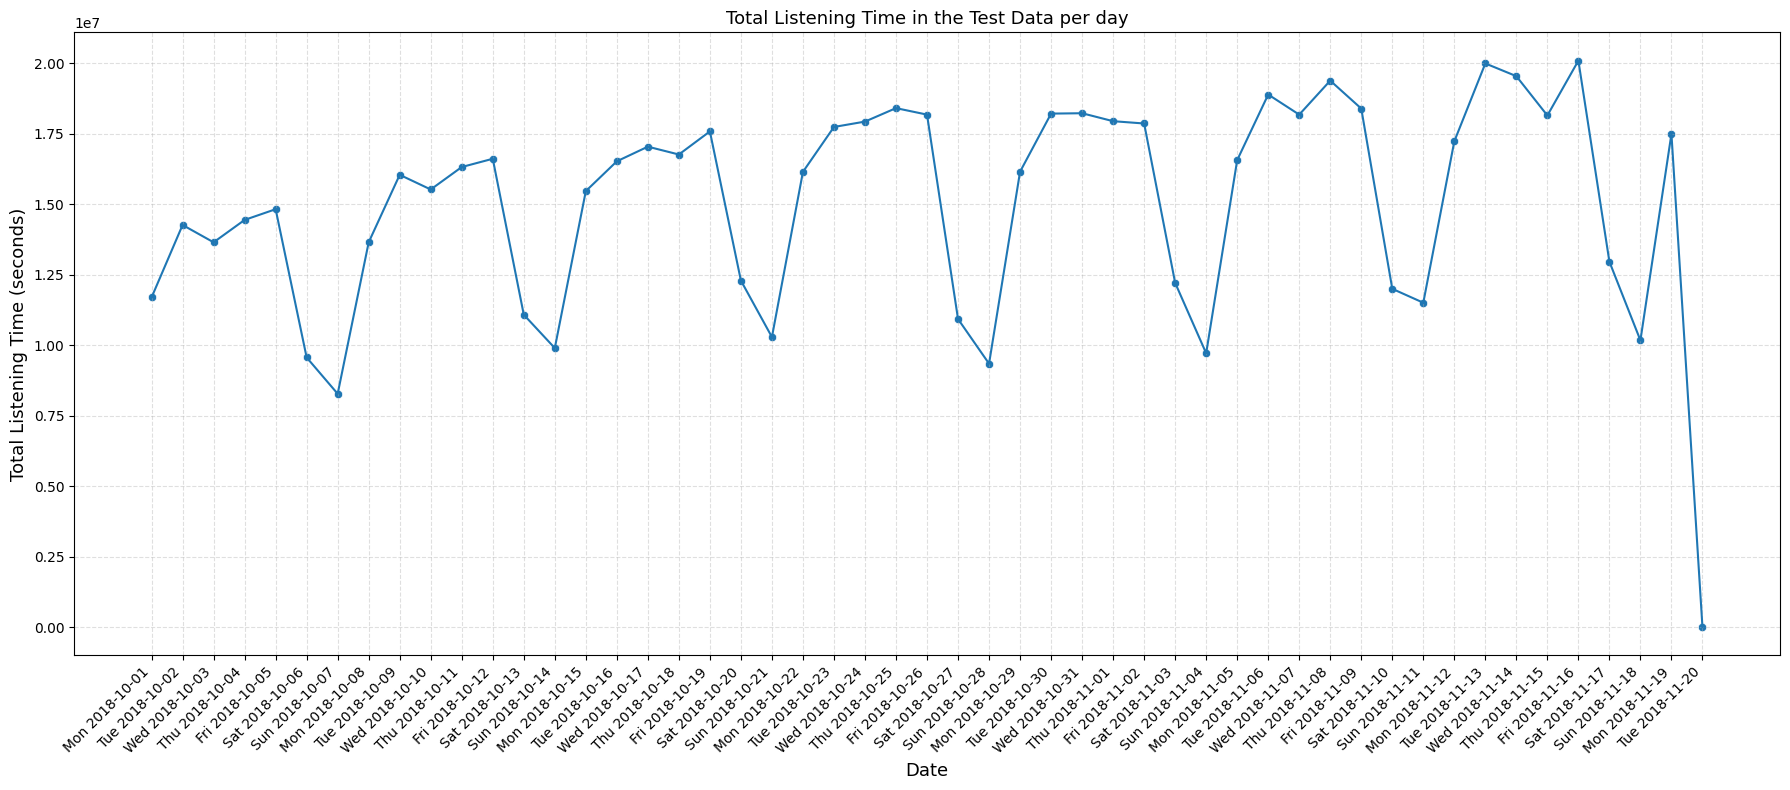

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

df_total_time_df["date"] = pd.to_datetime(df_total_time_df["date"]).dt.date

fig, ax = plt.subplots(figsize=(18, 8))

#sns.scatterplot(data=df_total_time_df_cancelled_sum, x="date", y="Cancelled", ax = ax)
#sns.scatterplot(data=df_total_time_df, x="date", y ="churn", ax = ax)
#sns.lineplot(df_total_time_df_cancelled_sum, x = "date", y = "Cancelled", ax = ax)
#sns.lineplot(data=df_total_time_df, x="date", y ="churn", ax = ax)

sns.scatterplot(data=df_total_time_df, x="date", y ="length", ax = ax)
sns.lineplot(data=df_total_time_df, x="date", y ="length", ax = ax)

ax.grid(True, which="both", axis="both", linestyle="--", alpha=0.4)

ax.set_xlabel("Date", fontsize=13)
ax.set_ylabel("Total Listening Time (seconds)", fontsize=13)
ax.set_title("Total Listening Time in the Test Data per day", fontsize=13)


# all dates as ticks + weekday name
ax.set_xticks(df_total_time_df["date"])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %Y-%m-%d"))  # e.g. Mon 2018-10-01

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
plt.show()


In [8]:
# Amount listened to music in the last 7 days

temp = df[["userId", "date", "length", "page"]].copy()

temp["time_one_app"] = temp.groupby(["userId"])["length"].transform("sum")

temp["time_on_app_minutes"] = temp["time_one_app"] / 60


temp["Canceled"] = temp["page"] == "Cancellation Confirmed"
temp["Canceled"] = temp["Canceled"].astype(int)

